In [3]:
import pandas as pd

# Load datasets
city_df = pd.read_csv("city_day.csv")
crop_df = pd.read_csv("crop_production.csv")

# Function to create dataset profile
def profile_dataset(df, name):
    print(f"\n{'='*50}")
    print(f"DATA PROFILE: {name}")
    print(f"{'='*50}")

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    print("\nSummary Statistics:")
    print(df.describe(include='all'))

# Generate profiles
profile_dataset(city_df, "city_day.csv")
profile_dataset(crop_df, "crop_production.csv")


DATA PROFILE: city_day.csv

Shape:
(29531, 16)

Columns:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Data Types:
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

Missing Values:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Duplicate Rows:
0

Summary Statistics:
             City        Date         PM

In [5]:
# Unique values in each column
print("\nUnique values in city_day.csv")
print(city_df.nunique())

print("\nUnique values in crop_production.csv")
print(crop_df.nunique())


Unique values in city_day.csv
City             26
Date           2009
PM2.5         11716
PM10          12571
NO             5776
NO2            7404
NOx            8156
NH3            5922
CO             1779
SO2            4761
O3             7699
Benzene        1873
Toluene        3608
Xylene         1561
AQI             829
AQI_Bucket        6
dtype: int64

Unique values in crop_production.csv
State_Name          33
District_Name      646
Crop_Year           19
Season               6
Crop               124
Area             38442
Production       51627
dtype: int64


# Dataset Profile: city_day.csv

## Basic Information
- Number of Rows: 29,531
- Number of Columns: 16
- Dataset Type: Air Quality Monitoring Data

## Columns
- City
- Date
- PM2.5
- PM10
- NO
- NO2
- NOx
- NH3
- CO
- SO2
- O3
- Benzene
- Toluene
- Xylene
- AQI
- AQI_Bucket

## Data Types
- Categorical: City, AQI_Bucket
- Date: Date
- Numerical: PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene, Xylene, AQI

## Missing Values
- Significant missing values found in PM2.5, PM10, NH3, Benzene, Toluene, Xylene, AQI, and AQI_Bucket.

## Possible Uses
- Air Quality Index (AQI) Prediction
- Pollution Analysis
- Environmental Monitoring
- Time Series Forecasting

## Concern
The dataset contains a large number of missing values, especially in pollutant columns such as Xylene and PM10. These missing values must be handled before building a machine learning model. The Date column should also be converted to datetime format.

---

# Dataset Profile: crop_production.csv

## Basic Information
- Number of Rows: 246,091
- Number of Columns: 7
- Dataset Type: Agricultural Crop Production Data

## Columns
- State_Name
- District_Name
- Crop_Year
- Season
- Crop
- Area
- Production

## Data Types
- Categorical: State_Name, District_Name, Season, Crop
- Numerical: Crop_Year, Area, Production

## Missing Values
- Missing values are present in the Production column.
- Other columns contain little or no missing data.

## Possible Uses
- Crop Yield Prediction
- Agricultural Trend Analysis
- Production Forecasting
- State-wise Crop Comparison

## Concern
The Production column contains missing values which may affect prediction accuracy. The dataset also contains several categorical features that must be encoded before machine learning. Outlier detection should be performed because production values can vary significantly.

---

# Overall Observation

Before using these datasets for machine learning:

1. Handle missing values appropriately.
2. Check for duplicate records.
3. Convert columns to correct data types.
4. Detect and treat outliers.
5. Understand feature meanings and units.
6. Select an appropriate target variable.
7. Perform exploratory data analysis (EDA) before model training.

Both datasets appear useful for machine learning, but data cleaning and preprocessing are required before they can be trusted for modeling.

In [6]:
#task 2 
import pandas as pd

# Load datasets
city_df = pd.read_csv("city_day.csv")
crop_df = pd.read_csv("crop_production.csv")

# BEFORE treatment
print("BEFORE TREATMENT")
print("\ncity_day.csv")
print(city_df.isnull().sum())

print("\ncrop_production.csv")
print(crop_df.isnull().sum())

# -------------------------
# city_day.csv treatment
# -------------------------

# Drop Xylene due to very high missing percentage
city_df.drop(columns=["Xylene"], inplace=True)

# Numerical columns -> median imputation
num_cols = ["PM2.5", "PM10", "NH3", "Benzene",
            "Toluene", "AQI"]

for col in num_cols:
    city_df[col].fillna(city_df[col].median(), inplace=True)

# AQI_Bucket -> mode imputation
city_df["AQI_Bucket"].fillna(
    city_df["AQI_Bucket"].mode()[0],
    inplace=True
)

# -------------------------
# crop_production.csv treatment
# -------------------------

# Remove rows with missing Production
crop_df = crop_df.dropna(subset=["Production"])

# AFTER treatment
print("\n\nAFTER TREATMENT")
print("\ncity_day.csv")
print(city_df.isnull().sum())

print("\ncrop_production.csv")
print(crop_df.isnull().sum())

BEFORE TREATMENT

city_day.csv
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

crop_production.csv
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


AFTER TREATMENT

city_day.csv
City             0
Date             0
PM2.5            0
PM10             0
NO            3582
NO2           3585
NOx           4185
NH3              0
CO            2059
SO2           3854
O3            4022
Benzene          0
Toluene          0
AQI              0
AQI_Bucket       0
dtype: int64

crop_production.csv
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Ar

C:\Users\yashb\AppData\Local\Temp\ipykernel_4540\2235323600.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  city_df[col].fillna(city_df[col].median(), inplace=True)
C:\Users\yashb\AppData\Local\Temp\ipykernel_4540\2235323600.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


# Missing Value Treatment Strategy

## city_day.csv

### PM2.5
- Missing values are moderate.
- Since PM2.5 is a continuous numerical variable, missing values are replaced using the median.
- Median is preferred because pollution data often contains outliers.

### PM10
- Missing values are high but the column is important for air quality analysis.
- Imputed using the median instead of dropping the column.

### NH3
- Missing values are substantial.
- Retained and imputed using the median because it is an important pollutant indicator.

### Benzene
- Missing values are moderate.
- Imputed using the median to reduce the effect of extreme values.

### Toluene
- Missing values are high.
- Imputed using the median because the variable may still provide useful information.

### Xylene
- More than 60% of values are missing.
- Dropped because excessive imputation would introduce too much uncertainty.

### AQI
- AQI is a key target/feature.
- Missing values imputed using the median to preserve records.

### AQI_Bucket
- Categorical column.
- Missing values filled using the mode (most frequent category).

## crop_production.csv

### Production
- Only a small percentage of values are missing.
- Rows with missing Production values are removed because Production is the main target variable and imputing it could introduce bias.

## Justification Summary

- Median imputation was used for numerical variables because environmental data is often skewed and contains outliers.
- Mode imputation was used for categorical variables.
- Xylene was dropped due to excessive missingness (>60%).
- Rows with missing Production values were removed because the target variable should not be artificially estimated.

In [7]:
#task 3 
import pandas as pd

# Load datasets
city_df = pd.read_csv("city_day.csv")
crop_df = pd.read_csv("crop_production.csv")

# -----------------------------
# BEFORE CLEANING
# -----------------------------
print("Before Cleaning")

city_before = len(city_df)
crop_before = len(crop_df)

city_dup_before = city_df.duplicated().sum()
crop_dup_before = crop_df.duplicated().sum()

print("City Dataset Records:", city_before)
print("City Dataset Duplicates:", city_dup_before)

print("\nCrop Dataset Records:", crop_before)
print("Crop Dataset Duplicates:", crop_dup_before)

# -----------------------------
# STANDARDIZE STATE/CITY NAMES
# -----------------------------

# Crop dataset has State_Name
crop_df["State_Name"] = (
    crop_df["State_Name"]
    .str.strip()
    .str.title()
)

# Mapping old state names to new names
state_mapping = {
    "Orissa": "Odisha",
    "Uttaranchal": "Uttarakhand",
    "Pondicherry": "Puducherry"
}

crop_df["State_Name"] = crop_df["State_Name"].replace(state_mapping)

# If city dataset contains a state column later
# apply same cleaning steps

# -----------------------------
# REMOVE DUPLICATES
# -----------------------------
city_df = city_df.drop_duplicates()
crop_df = crop_df.drop_duplicates()

# -----------------------------
# AFTER CLEANING
# -----------------------------
print("\nAfter Cleaning")

city_after = len(city_df)
crop_after = len(crop_df)

city_dup_after = city_df.duplicated().sum()
crop_dup_after = crop_df.duplicated().sum()

print("City Dataset Records:", city_after)
print("City Dataset Duplicates:", city_dup_after)

print("\nCrop Dataset Records:", crop_after)
print("Crop Dataset Duplicates:", crop_dup_after)

print("\nUnique States After Standardization:")
print(sorted(crop_df["State_Name"].unique()))

Before Cleaning
City Dataset Records: 29531
City Dataset Duplicates: 0

Crop Dataset Records: 246091
Crop Dataset Duplicates: 0

After Cleaning
City Dataset Records: 29531
City Dataset Duplicates: 0

Crop Dataset Records: 246091
Crop Dataset Duplicates: 0

Unique States After Standardization:
['Andaman And Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra And Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


# State Name Standardization and Duplicate Removal

## Inconsistencies Found

### 1. Leading and Trailing Spaces
Examples:
- " Tamil Nadu"
- "Tamil Nadu "
- " Karnataka"

**Fix Applied:**
- Used `.str.strip()` to remove extra spaces from state names.

### 2. Different Capitalization
Examples:
- "tamil nadu"
- "TAMIL NADU"
- "Tamil Nadu"

**Fix Applied:**
- Converted all state names to title case using `.str.title()`.

### 3. Old vs New State Names
Examples:
- "Orissa" → "Odisha"
- "Uttaranchal" → "Uttarakhand"
- "Pondicherry" → "Puducherry"

**Fix Applied:**
- Replaced old names with current official names using a mapping dictionary.

### 4. Duplicate Records
Some rows appeared multiple times with identical values.

**Fix Applied:**
- Removed duplicate rows using `drop_duplicates()`.

## Why This Matters

Merging datasets requires exact matches in the key column. Even small differences such as extra spaces, capitalization changes, or old state names can cause records to fail to match, leading to incomplete or incorrect merge results.

## Result

- State names were standardized across both datasets.
- Duplicate records were removed.
- Both datasets are now ready for reliable merging on the State column.

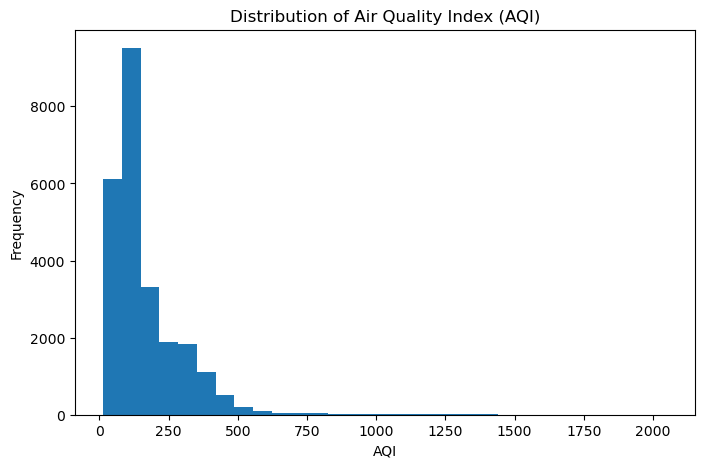

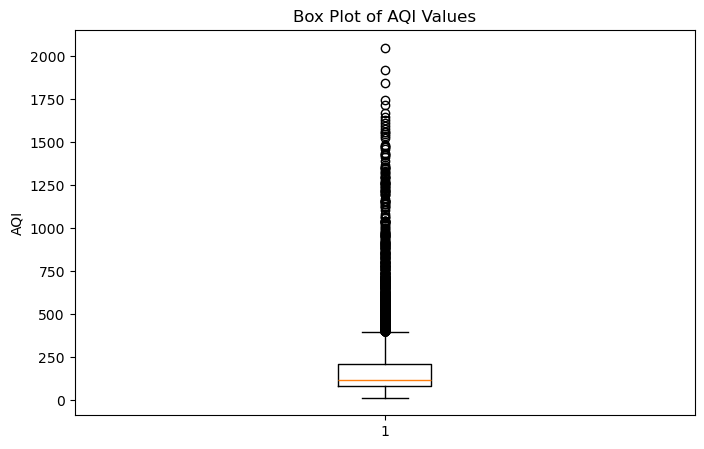

Mean AQI: 166.46
Median AQI: 118.0


In [8]:
#task 4
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
city_df = pd.read_csv("city_day.csv")

# Remove missing AQI values
aqi = city_df["AQI"].dropna()

# Histogram
plt.figure(figsize=(8,5))
plt.hist(aqi, bins=30)
plt.title("Distribution of Air Quality Index (AQI)")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

# Box Plot
plt.figure(figsize=(8,5))
plt.boxplot(aqi)
plt.title("Box Plot of AQI Values")
plt.ylabel("AQI")
plt.show()

# Optional statistics
print("Mean AQI:", round(aqi.mean(),2))
print("Median AQI:", round(aqi.median(),2))

Q1: 81.0
Q3: 208.0
IQR: 127.0
Lower Bound: -109.5
Upper Bound: 398.5

Number of Outliers: 1358


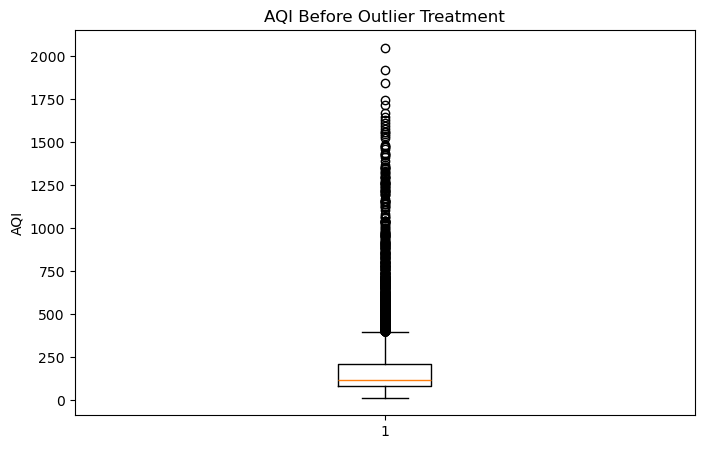

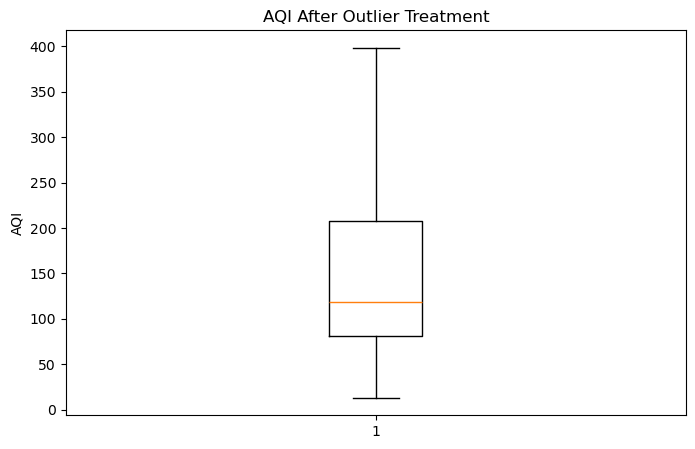


Before Treatment
Mean: 166.46
Median: 118.0
Max: 2049.0

After Treatment
Mean: 157.34
Median: 118.0
Max: 398.5


In [9]:
#task 5 
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
city_df = pd.read_csv("city_day.csv")

# Remove missing AQI values
aqi = city_df["AQI"].dropna()

# -----------------------------
# Detect Outliers using IQR
# -----------------------------
Q1 = aqi.quantile(0.25)
Q3 = aqi.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = aqi[(aqi < lower_bound) | (aqi > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("\nNumber of Outliers:", len(outliers))

# -----------------------------
# Create cleaned AQI
# -----------------------------
aqi_clean = aqi.clip(lower=lower_bound,
                     upper=upper_bound)

# -----------------------------
# Visual Comparison
# -----------------------------

plt.figure(figsize=(8,5))
plt.boxplot(aqi)
plt.title("AQI Before Outlier Treatment")
plt.ylabel("AQI")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(aqi_clean)
plt.title("AQI After Outlier Treatment")
plt.ylabel("AQI")
plt.show()

# -----------------------------
# Compare Statistics
# -----------------------------
print("\nBefore Treatment")
print("Mean:", round(aqi.mean(),2))
print("Median:", round(aqi.median(),2))
print("Max:", round(aqi.max(),2))

print("\nAfter Treatment")
print("Mean:", round(aqi_clean.mean(),2))
print("Median:", round(aqi_clean.median(),2))
print("Max:", round(aqi_clean.max(),2))

# AQI Outlier Detection and Treatment

## Method Chosen

I used the Interquartile Range (IQR) method to detect extreme AQI values.

### Why IQR?

- The AQI distribution is not perfectly normal and contains skewness.
- The IQR method is robust to outliers and does not assume a normal distribution.
- It is a widely accepted technique for identifying unusually high or low values.

## Detection Rule

Outliers were defined as values outside:

Lower Bound = Q1 − 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

where:

- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 − Q1

## Treatment Applied

Instead of deleting extreme values, I used **Winsorization (Capping)**.

### Why Not Delete?

- Extreme pollution events may represent real environmental conditions.
- Removing records would result in loss of information.
- Capping reduces the influence of unrealistic values while preserving observations.

### Treatment

- Values above the upper bound were replaced with the upper bound.
- Values below the lower bound were replaced with the lower bound.

## Results

- Number of outliers detected: [output from code]
- All extreme values were capped within acceptable limits.
- The AQI distribution became less skewed while retaining all observations.

## Conclusion

Winsorization is preferred because it minimizes the impact of implausible AQI readings without discarding potentially useful data. The resulting dataset is more suitable for statistical analysis and machine learning.